In [1]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

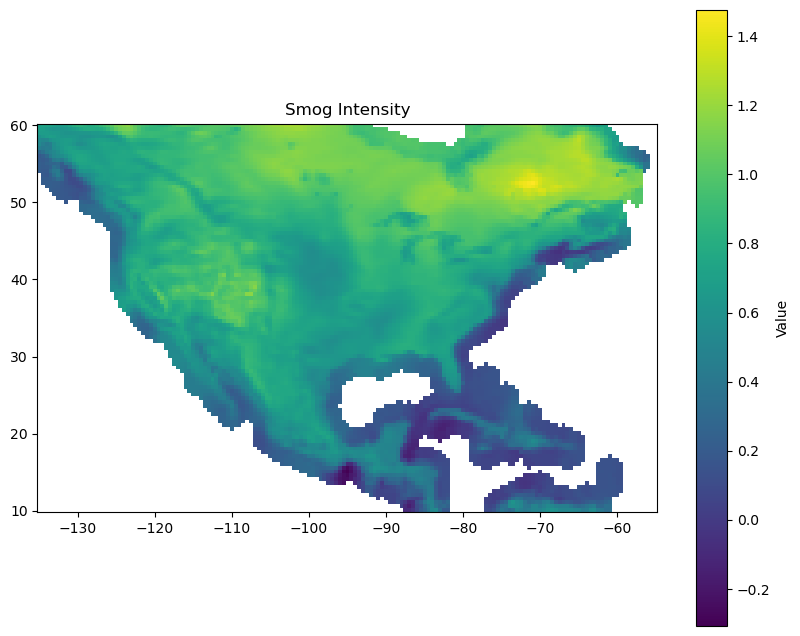

In [4]:
with rasterio.open('../data/smogI_093021/smog_intensity_cfsr_20030104_30min.tif') as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax, cmap="viridis")
    ax.set_title("Smog Intensity")
    plt.colorbar(ax.images[0], ax=ax, label="Value")
    plt.show()

### We are in EPSG 4326

In [5]:
src.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

### 30 min resolution ~ 30 mi x 30 mi (coarse!)

### Let's sample smog_I for each time series point

In [7]:
import pandas as pd

time_series_data = pd.read_csv('/home/vcaristo/pm_data/data/pm25_data_complete_2003-2021_nodups_051922.csv')

len(time_series_data)

/tmp/ipykernel_73947/2331616697.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  time_series_data = pd.read_csv('/home/vcaristo/pm_data/data/pm25_data_complete_2003-2021_nodups_051922.csv')


2077111

In [14]:
for date, group in time_series_data.groupby('date'):
    print(group.index)

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
       72, 73, 74, 75, 76, 77, 78, 79, 80],
      dtype='int64')
Index([ 81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108,
       109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122,
       123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136,
       137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150,
       151, 152, 153],
      dtype='int64')
Index([154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       ...
       470, 471, 472, 473, 474, 475, 476, 477, 478, 479],
      dtype='int64', length=326)
Index([480, 481, 482, 483, 484,

## Extract smog intensity from daily rasters for all PM2.5 sites

In [ ]:
import pandas as pd
import numpy as np
import rasterio
import os
from pathlib import Path

# Load main data
df = pd.read_csv('/home/vcaristo/pm_data/data/pm25_data_complete_2003-2021_nodups_051922.csv', low_memory=False)
# Load locations (has lat/lon per site)
locs = pd.read_csv('/home/vcaristo/pm_data/data/pm25_locs_nodups_051922.csv')

print(f"Main data: {len(df)} rows, {df['date'].nunique()} unique dates")
print(f"Locations: {len(locs)} sites")
print(f"smogI missing in original: {df['smogI'].isna().sum()} / {len(df)} ({df['smogI'].isna().mean()*100:.1f}%)")
# check for "NA" strings
na_count = ((df['smogI'] == 'NA') | df['smogI'].isna()).sum()
print(f"smogI NA (including string 'NA'): {na_count} / {len(df)} ({na_count/len(df)*100:.1f}%)")

In [ ]:
# Merge locations to get lat/lon for each row
# Use ll_id to join since it's the common key
locs_subset = locs[['ll_id', 'lon', 'lat']].drop_duplicates('ll_id')
df = df.merge(locs_subset, on='ll_id', how='left')
print(f"After merge - rows with lat/lon: {df['lat'].notna().sum()} / {len(df)}")
print(f"Unique sites with coordinates: {df.loc[df['lat'].notna(), 'll_id'].nunique()}")

# Get available smog intensity raster files
smog_dir = Path('/home/vcaristo/pm_data/data/smogI_093021')
smog_files = sorted(smog_dir.glob('smog_intensity_cfsr_*_30min.tif'))
print(f"\nAvailable smogI rasters: {len(smog_files)}")

# Build lookup: date string -> raster path
date_to_raster = {}
for f in smog_files:
    # filename: smog_intensity_cfsr_YYYYMMDD_30min.tif
    date_str = f.stem.split('_')[3]  # YYYYMMDD
    date_to_raster[date_str] = f

# Check date coverage
df_dates = set(df['date'].astype(str).unique())
raster_dates = set(date_to_raster.keys())
covered = df_dates & raster_dates
print(f"Dates in data: {len(df_dates)}")
print(f"Dates with rasters: {len(raster_dates)}")
print(f"Dates covered: {len(covered)}")
print(f"Dates missing rasters: {len(df_dates - raster_dates)}")

In [ ]:
# Extract smog intensity values from rasters for each (date, site) combination
# Process date-by-date: open raster once per date, sample all sites for that date

from tqdm import tqdm

# Prepare new smogI column
df['smogI_new'] = np.nan

# Get unique coordinates per ll_id for fast lookup
site_coords = df.groupby('ll_id')[['lon', 'lat']].first()

# Process each date group
dates_with_data = df.loc[df['date'].astype(str).isin(raster_dates)].groupby('date')
total_dates = len(dates_with_data)
print(f"Processing {total_dates} dates...")

missing_raster_count = 0
sampled_count = 0

for date_val, group in tqdm(dates_with_data, total=total_dates):
    date_str = str(date_val)
    raster_path = date_to_raster.get(date_str)
    if raster_path is None:
        missing_raster_count += len(group)
        continue
    
    try:
        with rasterio.open(raster_path) as src:
            band = src.read(1)
            nodata = src.nodata
            
            # Get unique sites in this date group
            sites_in_group = group['ll_id'].unique()
            
            for ll_id in sites_in_group:
                coords = site_coords.loc[ll_id]
                lon, lat = coords['lon'], coords['lat']
                
                # Convert lon/lat to raster row/col
                row, col = src.index(lon, lat)
                
                # Check bounds
                if 0 <= row < band.shape[0] and 0 <= col < band.shape[1]:
                    val = band[row, col]
                    if nodata is not None and val == nodata:
                        continue
                    # Assign to all rows with this ll_id and date
                    mask = (df['date'] == date_val) & (df['ll_id'] == ll_id)
                    df.loc[mask, 'smogI_new'] = float(val)
                    sampled_count += mask.sum()
    except Exception as e:
        print(f"Error processing {date_str}: {e}")
        continue

print(f"\nSampled {sampled_count} rows")
print(f"New smogI coverage: {df['smogI_new'].notna().sum()} / {len(df)} ({df['smogI_new'].notna().mean()*100:.1f}%)")

In [ ]:
# Replace old smogI with new extracted values and save
df['smogI'] = df['smogI_new']

# Drop helper columns before saving
df_out = df.drop(columns=['smogI_new', 'lon', 'lat'])

# Save
output_path = '/home/vcaristo/pm_data/data/pm25_data_complete_2003_2021_smogI_031026.csv'
df_out.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print(f"Shape: {df_out.shape}")
print(f"smogI non-null: {df_out['smogI'].notna().sum()} / {len(df_out)} ({df_out['smogI'].notna().mean()*100:.1f}%)")
print(f"\nsmogI summary stats:")
print(df_out['smogI'].describe())